In [1]:
# ==============================================================================
# SECTION 1: IMPORTS AND GPU VERIFICATION
# ==============================================================================
# This section imports all necessary libraries and confirms GPU availability.

# --- Standard Libraries ---
import numpy as np  # For numerical operations, especially with arrays.
import pandas as pd  # For data manipulation and analysis (we'll use DataFrames).
import matplotlib.pyplot as plt  # For creating static, animated, and interactive visualizations.
import seaborn as sns  # A high-level interface for drawing attractive and informative statistical graphics.
import os  # Provides a way of using operating system dependent functionality.
from tqdm import tqdm  # A fast, extensible progress bar for loops and other iterables.

# --- TensorFlow and Keras for Deep Learning ---
import tensorflow as tf
from tensorflow.keras.models import Model  # The base class for creating Keras models.
from tensorflow.keras.layers import Input, Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.applications import ResNet50V2, EfficientNetB0  # Importing our pre-trained baseline models.
from tensorflow.keras.applications.resnet_v2 import preprocess_input as resnet_preprocess # Model-specific preprocessing
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess # Model-specific preprocessing
from tensorflow.keras.optimizers import Adam  # A popular optimization algorithm.
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau  # Helper functions during training.

# --- Scikit-learn for Performance Metrics ---
from sklearn.model_selection import train_test_split  # To split our data into train, validation, and test sets.
from sklearn.metrics import (accuracy_score, f1_score, cohen_kappa_score, 
                             roc_auc_score, mean_squared_error, confusion_matrix)
from scipy.stats import pearsonr  # For calculating Pearson's correlation coefficient.

# --- GPU Verification ---
# This code block checks if TensorFlow can detect a GPU.
print("TensorFlow Version:", tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        # Set memory growth to True to prevent TensorFlow from allocating all GPU memory at once.
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"GPU(s) detected: {len(gpus)} devices.")
        logical_gpus = tf.config.list_logical_devices('GPU')
        print(f"Logical GPUs: {len(logical_gpus)}")
    except RuntimeError as e:
        # Memory growth must be set before GPUs have been initialized
        print(e)
else:
    print("No GPU detected. Running on CPU.")

2025-10-06 19:21:42.291024: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1759778502.679126      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1759778502.808649      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


TensorFlow Version: 2.18.0
GPU(s) detected: 2 devices.
Logical GPUs: 2


I0000 00:00:1759778520.377916      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1759778520.378723      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [2]:
# ==============================================================================
# SECTION 2: CONFIGURATION AND DATA PATHS (FINAL CORRECTED VERSION)
# ==============================================================================
# This section defines project constants and the correct paths to the dataset.

# --- Configuration Constants ---
IMG_SIZE = 224  # The required input size for our models (224x224 pixels).
BATCH_SIZE = 64  # The number of samples to process in each batch.
NUM_CLASSES = 8  # There are 8 emotion categories (0 through 7).
AUTOTUNE = tf.data.experimental.AUTOTUNE  # TF will auto-tune performance.

# --- Define Direct Paths to Data ---
# Based on your os.walk output, the data is not zipped and is located directly
# in the /kaggle/input/ directory with a nested structure.
# We will define these paths directly.

# The main folder name you gave your dataset in Kaggle.
KAGGLE_INPUT_DIR = '/kaggle/input/deep-learning/'

# The full, correct paths to the images and annotations folders.
BASE_PATH = os.path.join(KAGGLE_INPUT_DIR, 'Dataset/Dataset')
IMAGES_PATH = os.path.join(BASE_PATH, 'images')
ANNOTATIONS_PATH = os.path.join(BASE_PATH, 'annotations')

# --- Final Check to Ensure Paths are Correct ---
# This will stop the notebook if the paths are still wrong, preventing further errors.
if not os.path.isdir(ANNOTATIONS_PATH):
    raise FileNotFoundError(f"FATAL ERROR: The annotations directory was not found at '{ANNOTATIONS_PATH}'. Please double-check your dataset's folder structure in the Kaggle input directory.")
else:
    print("Successfully located the annotations directory.")
    
if not os.path.isdir(IMAGES_PATH):
    raise FileNotFoundError(f"FATAL ERROR: The images directory was not found at '{IMAGES_PATH}'. Please double-check your dataset's folder structure.")
else:
    print("Successfully located the images directory.")
    print("\nPaths are correctly configured. Proceeding to data loading.")

Successfully located the annotations directory.
Successfully located the images directory.

Paths are correctly configured. Proceeding to data loading.


In [3]:
# ==============================================================================
# SECTION 3: DATA LOADING AND PREPARATION
# ==============================================================================
# This section loads annotations, cleans the data, and splits it into sets.

def load_and_prepare_data(annotations_path, images_path):
    """
    Loads all annotations, filters out invalid samples, and creates a clean
    pandas DataFrame linking images to their labels.
    
    Args:
        annotations_path (str): Path to the directory with .npy annotation files.
        images_path (str): Path to the directory with image files.
        
    Returns:
        pd.DataFrame: A DataFrame with columns ['image_path', 'expression', 'valence', 'arousal'].
    """
    # Get a sorted list of all expression annotation files.
    annotation_files = sorted([f for f in os.listdir(annotations_path) if f.endswith('_exp.npy')])
    
    all_data = []  # A list to store data for each valid sample.
    
    print("Loading annotations and building DataFrame...")
    # Use tqdm to show a progress bar as we iterate through files.
    for ann_file in tqdm(annotation_files):
        # Extract the image ID from the annotation filename (e.g., '123_exp.npy' -> '123').
        image_id = ann_file.split('_')[0]
        image_path = os.path.join(images_path, f"{image_id}.jpg")
        
        # Check if the image file actually exists to avoid errors.
        if os.path.exists(image_path):
            # Load the three annotations for this image using numpy.
            expression = np.load(os.path.join(annotations_path, ann_file))
            valence = np.load(os.path.join(annotations_path, f"{image_id}_val.npy"))
            arousal = np.load(os.path.join(annotations_path, f"{image_id}_aro.npy"))
            
            # --- DATA FILTERING ---
            # The problem states that valence/arousal are -2 for invalid categories.
            # We must remove these samples to train the regression model properly.
            if valence != -2 and arousal != -2:
                # If the data is valid, append it as a dictionary to our list.
                all_data.append({
                    'image_path': image_path,
                    'expression': int(expression),
                    'valence': float(valence),
                    'arousal': float(arousal)
                })
                
    # Convert the list of dictionaries into a pandas DataFrame.
    return pd.DataFrame(all_data)

# --- Execute Data Loading ---
affectnet_df = load_and_prepare_data(ANNOTATIONS_PATH, IMAGES_PATH)
print(f"\nSuccessfully loaded {len(affectnet_df)} valid samples.")
print("DataFrame Head:")
print(affectnet_df.head())

# --- Split the Dataset ---
# We split the data into training (80%), validation (10%), and testing (10%) sets.
# 'stratify' ensures that the proportion of each emotion class is the same across all splits.
print("\nSplitting the dataset...")
train_df, test_val_df = train_test_split(
    affectnet_df, 
    test_size=0.2,
    random_state=42,
    stratify=affectnet_df['expression']
)
val_df, test_df = train_test_split(
    test_val_df,
    test_size=0.5,
    random_state=42,
    stratify=test_val_df['expression']
)

print(f"Training samples:   {len(train_df)}")
print(f"Validation samples: {len(val_df)}")
print(f"Test samples:       {len(test_df)}")

Loading annotations and building DataFrame...


100%|██████████| 3999/3999 [01:21<00:00, 49.02it/s]


Successfully loaded 3999 valid samples.
DataFrame Head:
                                          image_path  expression   valence  \
0  /kaggle/input/deep-learning/Dataset/Dataset/im...           0 -0.176846   
1  /kaggle/input/deep-learning/Dataset/Dataset/im...           0 -0.135501   
2  /kaggle/input/deep-learning/Dataset/Dataset/im...           4 -0.114510   
3  /kaggle/input/deep-learning/Dataset/Dataset/im...           5 -0.642857   
4  /kaggle/input/deep-learning/Dataset/Dataset/im...           2 -0.796971   

    arousal  
0 -0.077640  
1  0.004839  
2  0.857748  
3  0.484127  
4 -0.229129  

Splitting the dataset...
Training samples:   3199
Validation samples: 400
Test samples:       400


In [4]:
# ==============================================================================
# SECTION 4: TF.DATA PIPELINE FOR EFFICIENT TRAINING
# ==============================================================================

# --- Data Augmentation Layers ---
# Augmentation creates modified versions of our training images on-the-fly.
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1),
], name='data_augmentation')

# --- Data Pipeline Function ---
def create_dataset(df, is_training=True, augmentation_fn=None, preprocess_fn=None):
    """
    Creates a tf.data.Dataset from a pandas DataFrame for model training.
    """
    # Create a dataset slice from the image file paths.
    image_paths_ds = tf.data.Dataset.from_tensor_slices(df['image_path'].values)
    
    # --- Create datasets for labels ---
    expression_labels = tf.constant(df['expression'].values, dtype=tf.int32)
    expression_one_hot = tf.one_hot(expression_labels, depth=NUM_CLASSES)
    
    valence_labels = tf.constant(df['valence'].values, dtype=tf.float32)
    arousal_labels = tf.constant(df['arousal'].values, dtype=tf.float32)
    regression_labels = tf.stack([valence_labels, arousal_labels], axis=1)

    # --- Image Loading and Preprocessing Function ---
    def load_and_preprocess_image(path):
        """Loads an image file, decodes, resizes, and preprocesses it."""
        img = tf.io.read_file(path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
        if preprocess_fn:
            img = preprocess_fn(img)
        return img
    
    images_ds = image_paths_ds.map(load_and_preprocess_image, num_parallel_calls=AUTOTUNE)
    
    labels_ds = tf.data.Dataset.from_tensor_slices((expression_one_hot, regression_labels))
    
    dataset = tf.data.Dataset.zip((images_ds, labels_ds))
    
    # --- Training-Specific Operations ---
    if is_training:
        dataset = dataset.shuffle(buffer_size=len(df), reshuffle_each_iteration=True)
        if augmentation_fn:
            dataset = dataset.map(lambda x, y: (augmentation_fn(x, training=True), y), 
                                  num_parallel_calls=AUTOTUNE)

    # --- Performance Optimization ---
    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(buffer_size=AUTOTUNE)
    
    return dataset

In [5]:
# ==============================================================================
# SECTION 5: MULTI-TASK MODEL DEFINITION
# ==============================================================================

def build_multitask_model(base_model_fn, input_shape=(IMG_SIZE, IMG_SIZE, 3)):
    """
    Builds a multi-task CNN model using transfer learning.
    """
    # --- 1. Load the Base Model (Feature Extractor) ---
    base_model = base_model_fn(include_top=False, weights='imagenet', input_shape=input_shape)
    base_model.trainable = False
    
    # --- 2. Define Model Inputs ---
    inputs = Input(shape=input_shape)
    
    # --- 3. Build the Shared Layers ---
    x = base_model(inputs, training=False) 
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.4)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.4)(x)

    # --- 4. Create Task-Specific Output Heads ---
    classification_output = Dense(NUM_CLASSES, activation='softmax', name='classification_head')(x)
    regression_output = Dense(2, activation='tanh', name='regression_head')(x)

    # --- 5. Create and Compile the Final Model ---
    model = Model(inputs=inputs, outputs=[classification_output, regression_output])
    
    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss={
            'classification_head': 'categorical_crossentropy',
            'regression_head': 'mean_squared_error'
        },
        metrics={
            'classification_head': ['accuracy'],
            'regression_head': [tf.keras.metrics.RootMeanSquaredError(name='rmse')]
        }
    )
    
    return model

In [6]:
# ==============================================================================
# SECTION 6.1: TRAIN RESNET50V2 BASELINE
# ==============================================================================
print("\n--- Preparing ResNet50V2 Model ---")

# --- Create Datasets ---
print("Creating datasets for ResNet50V2...")
train_ds_resnet = create_dataset(train_df, is_training=True, augmentation_fn=data_augmentation, preprocess_fn=resnet_preprocess)
val_ds_resnet = create_dataset(val_df, is_training=False, preprocess_fn=resnet_preprocess)
test_ds_resnet = create_dataset(test_df, is_training=False, preprocess_fn=resnet_preprocess)

# --- Build the Model ---
resnet_model = build_multitask_model(ResNet50V2)
print("ResNet50V2 Model Summary:")
resnet_model.summary()

# --- Define Callbacks ---
callbacks_resnet = [
    ModelCheckpoint('best_resnet_model.h5', save_best_only=True, monitor='val_classification_head_accuracy', mode='max', verbose=1),
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6, verbose=1)
]

# --- Train the Model ---
print("\n--- Training ResNet50V2 Model ---")
history_resnet = resnet_model.fit(
    train_ds_resnet,
    validation_data=val_ds_resnet,
    epochs=30,
    callbacks=callbacks_resnet
)


--- Preparing ResNet50V2 Model ---
Creating datasets for ResNet50V2...
94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
ResNet50V2 Model Summary:


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50v2          │ (None, 7, 7,      │ 23,564,800 │ input_layer_2[0]… │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50v2[0][0]  │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 2048)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │    262,272 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ classification_head │ (None, 8)         │      1,032 │ dropout_1[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ regression_head     │ (None, 2)         │        258 │ dropout_1[0][0]   │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,828,362 (90.90 MB)

 Trainable params: 263,562 (1.01 MB)

...


--- Training ResNet50V2 Model ---
Epoch 1/30


I0000 00:00:1759778622.388696      61 service.cc:148] XLA service 0x7fc3340103b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1759778622.390527      61 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1759778622.390554      61 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1759778624.481892      61 cuda_dnn.cc:529] Loaded cuDNN version 90300


 1/50 ━━━━━━━━━━━━━━━━━━━━ 22:54 28s/step - classification_head_accuracy: 0.2344 - classification_head_loss: 2.9594 - loss: 3.5643 - regression_head_loss: 0.6049 - regression_head_rmse: 0.7777

I0000 00:00:1759778634.534731      61 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 548ms/step - classification_head_accuracy: 0.1492 - classification_head_loss: 2.4421 - loss: 2.8909 - regression_head_loss: 0.4488 - regression_head_rmse: 0.6659
Epoch 1: val_classification_head_accuracy improved from -inf to 0.16250, saving model to best_resnet_model.h5
50/50 ━━━━━━━━━━━━━━━━━━━━ 65s 764ms/step - classification_head_accuracy: 0.1491 - classification_head_loss: 2.4379 - loss: 2.8843 - regression_head_loss: 0.4465 - regression_head_rmse: 0.6641 - val_classification_head_accuracy: 0.1625 - val_classification_head_loss: 2.0472 - val_loss: 2.2548 - val_regression_head_loss: 0.1996 - val_regression_head_rmse: 0.4512 - learning_rate: 0.0010
Epoch 2/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 371ms/step - classification_head_accuracy: 0.1673 - classification_head_loss: 2.0501 - loss: 2.2626 - regression_head_loss: 0.2125 - regression_head_rmse: 0.4609
Epoch 2: val_classification_head_accuracy improved from 0.16250 to 0.21000, saving model to best_resnet_mod

In [7]:
# ==============================================================================
# SECTION 6.2: TRAIN EFFICIENTNETB0 BASELINE
# ==============================================================================
print("\n--- Preparing EfficientNetB0 Model ---")

# --- Create Datasets ---
print("Creating datasets for EfficientNetB0...")
train_ds_effnet = create_dataset(train_df, is_training=True, augmentation_fn=data_augmentation, preprocess_fn=efficientnet_preprocess)
val_ds_effnet = create_dataset(val_df, is_training=False, preprocess_fn=efficientnet_preprocess)
test_ds_effnet = create_dataset(test_df, is_training=False, preprocess_fn=efficientnet_preprocess)

# --- Build the Model ---
efficientnet_model = build_multitask_model(EfficientNetB0)
print("EfficientNetB0 Model Summary:")
efficientnet_model.summary()

# --- Define Callbacks ---
callbacks_effnet = [
    ModelCheckpoint('best_efficientnet_model.h5', save_best_only=True, monitor='val_classification_head_accuracy', mode='max', verbose=1),
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6, verbose=1)
]

# --- Train the Model ---
print("\n--- Training EfficientNetB0 Model ---")
history_efficientnet = efficientnet_model.fit(
    train_ds_effnet,
    validation_data=val_ds_effnet,
    epochs=30,
    callbacks=callbacks_effnet
)


--- Preparing EfficientNetB0 Model ---
Creating datasets for EfficientNetB0...
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
EfficientNetB0 Model Summary:


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetb0      │ (None, 7, 7,      │  4,049,571 │ input_layer_4[0]… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ efficientnetb0[0… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 1280)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │    163,968 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 128)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ classification_head │ (None, 8)         │      1,032 │ dropout_3[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ regression_head     │ (None, 2)         │        258 │ dropout_3[0][0]   │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,214,829 (16.08 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 4,049,571 (15.45 MB)


--- Training EfficientNetB0 Model ---
Epoch 1/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 570ms/step - classification_head_accuracy: 0.1412 - classification_head_loss: 2.1317 - loss: 2.4081 - regression_head_loss: 0.2764 - regression_head_rmse: 0.5251
Epoch 1: val_classification_head_accuracy improved from -inf to 0.18500, saving model to best_efficientnet_model.h5
50/50 ━━━━━━━━━━━━━━━━━━━━ 73s 835ms/step - classification_head_accuracy: 0.1415 - classification_head_loss: 2.1311 - loss: 2.4067 - regression_head_loss: 0.2757 - regression_head_rmse: 0.5244 - val_classification_head_accuracy: 0.1850 - val_classification_head_loss: 2.0218 - val_loss: 2.2259 - val_regression_head_loss: 0.1931 - val_regression_head_rmse: 0.4431 - learning_rate: 0.0010
Epoch 2/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 343ms/step - classification_head_accuracy: 0.2194 - classification_head_loss: 2.0252 - loss: 2.2209 - regression_head_loss: 0.1957 - regression_head_rmse: 0.4423
Epoch 2: val_classification_head_accuracy improved 

In [8]:
# ==============================================================================
# SECTION 7: MODEL EVALUATION
# ==============================================================================

# --- Custom Metrics Implementation ---
def sign_agreement(y_true, y_pred):
    return np.mean(np.sign(y_true) == np.sign(y_pred))

def concordance_correlation_coefficient(y_true, y_pred):
    cor = np.corrcoef(y_true, y_pred)[0][1]
    mean_true, var_true, sd_true = np.mean(y_true), np.var(y_true), np.std(y_true)
    mean_pred, var_pred, sd_pred = np.mean(y_pred), np.var(y_pred), np.std(y_pred)
    numerator = 2 * cor * sd_true * sd_pred
    denominator = var_true + var_pred + (mean_true - mean_pred) ** 2
    return numerator / denominator

# --- Comprehensive Evaluation Function ---
def evaluate_model(model, test_dataset, test_df):
    print(f"\n--- Evaluating model: {model.layers[1].name} ---")
    
    y_pred_class_probs, y_pred_regr = model.predict(test_dataset)
    y_pred_class = np.argmax(y_pred_class_probs, axis=1)
    
    y_true_class = test_df['expression'].values
    y_true_valence = test_df['valence'].values
    y_true_arousal = test_df['arousal'].values

    print("Calculating classification metrics...")
    accuracy = accuracy_score(y_true_class, y_pred_class)
    f1 = f1_score(y_true_class, y_pred_class, average='macro')
    kappa = cohen_kappa_score(y_true_class, y_pred_class)
    auc = roc_auc_score(y_true_class, y_pred_class_probs, multi_class='ovr')
    
    print("Calculating regression metrics...")
    rmse_v = np.sqrt(mean_squared_error(y_true_valence, y_pred_regr[:, 0]))
    corr_v = pearsonr(y_true_valence, y_pred_regr[:, 0])[0]
    sagr_v = sign_agreement(y_true_valence, y_pred_regr[:, 0])
    ccc_v = concordance_correlation_coefficient(y_true_valence, y_pred_regr[:, 0])
    
    rmse_a = np.sqrt(mean_squared_error(y_true_arousal, y_pred_regr[:, 1]))
    corr_a = pearsonr(y_true_arousal, y_pred_regr[:, 1])[0]
    sagr_a = sign_agreement(y_true_arousal, y_pred_regr[:, 1])
    ccc_a = concordance_correlation_coefficient(y_true_arousal, y_pred_regr[:, 1])

    results = {
        'Accuracy': accuracy, 'F1-Score (macro)': f1, "Cohen's Kappa": kappa, 'AUC (ovr)': auc,
        'RMSE_Valence': rmse_v, 'CORR_Valence': corr_v, 'SAGR_Valence': sagr_v, 'CCC_Valence': ccc_v,
        'RMSE_Arousal': rmse_a, 'CORR_Arousal': corr_a, 'SAGR_Arousal': sagr_a, 'CCC_Arousal': ccc_a
    }
    return results

# --- Run Evaluation on Both Models ---
print("\nLoading best weights for final evaluation...")
resnet_model.load_weights('best_resnet_model.h5')
efficientnet_model.load_weights('best_efficientnet_model.h5')

resnet_results = evaluate_model(resnet_model, test_ds_resnet, test_df)
efficientnet_results = evaluate_model(efficientnet_model, test_ds_effnet, test_df)

# --- Display Results in a Comparison Table ---
results_df = pd.DataFrame([resnet_results, efficientnet_results], index=['ResNet50V2', 'EfficientNetB0'])
print("\n\n================================================")
print("       PERFORMANCE COMPARISON ON TEST SET       ")
print("================================================")
print(results_df.T.round(4))
print("================================================")


Loading best weights for final evaluation...

--- Evaluating model: resnet50v2 ---
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 741ms/step
Calculating classification metrics...
Calculating regression metrics...

--- Evaluating model: efficientnetb0 ---
7/7 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step
Calculating classification metrics...
Calculating regression metrics...


       PERFORMANCE COMPARISON ON TEST SET       
                  ResNet50V2  EfficientNetB0
Accuracy              0.2925          0.2750
F1-Score (macro)      0.2730          0.2708
Cohen's Kappa         0.1914          0.1714
AUC (ovr)             0.7227          0.7260
RMSE_Valence          0.4347          0.4297
CORR_Valence          0.3500          0.3671
SAGR_Valence          0.7025          0.6875
CCC_Valence           0.2004          0.2102
RMSE_Arousal          0.3613          0.3570
CORR_Arousal          0.2509          0.3035
SAGR_Arousal          0.7825          0.7825
CCC_Arousal           0.1061          0.1678


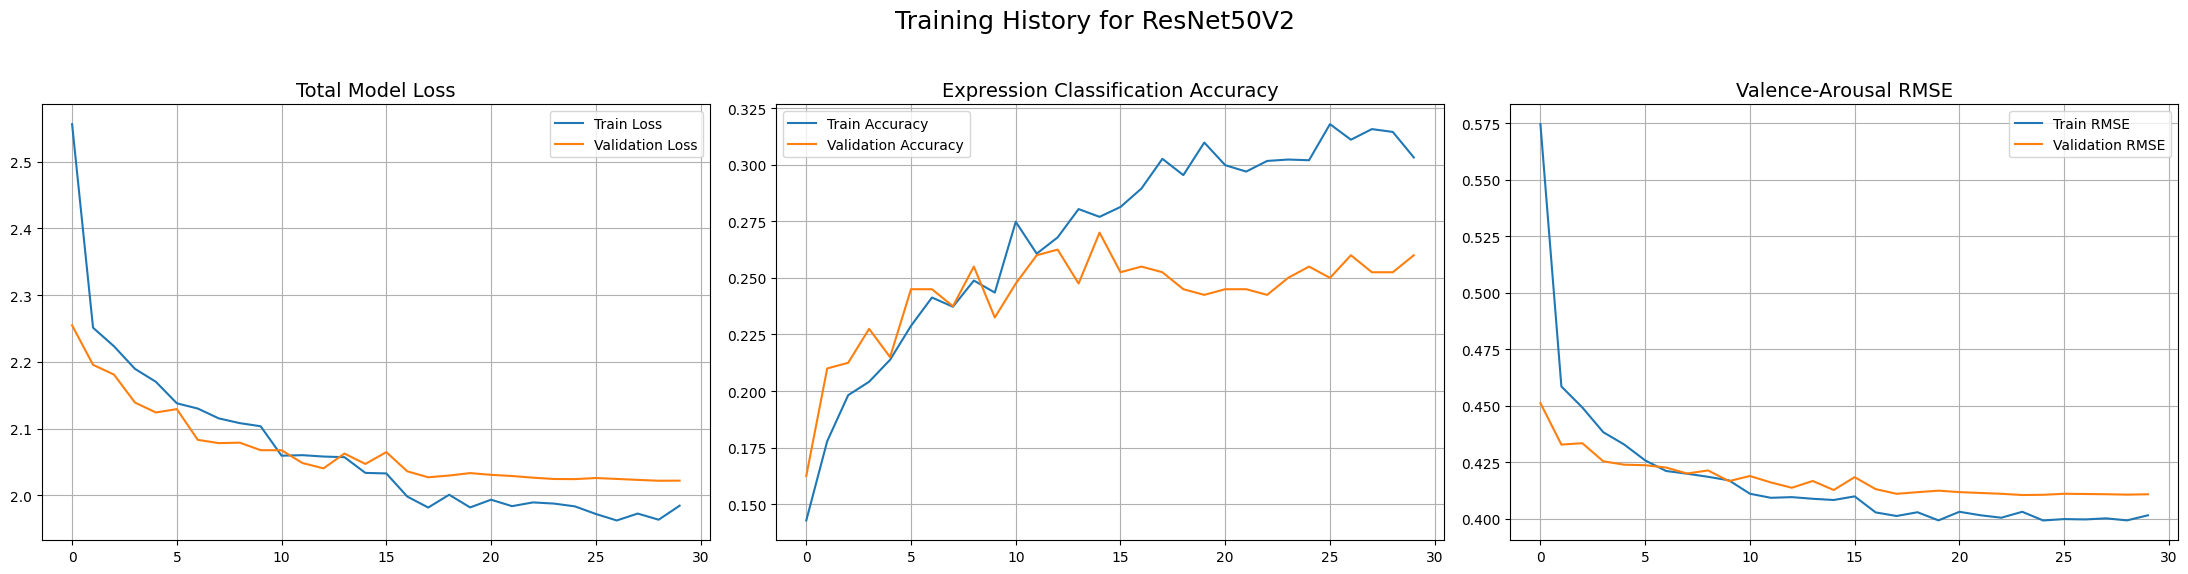

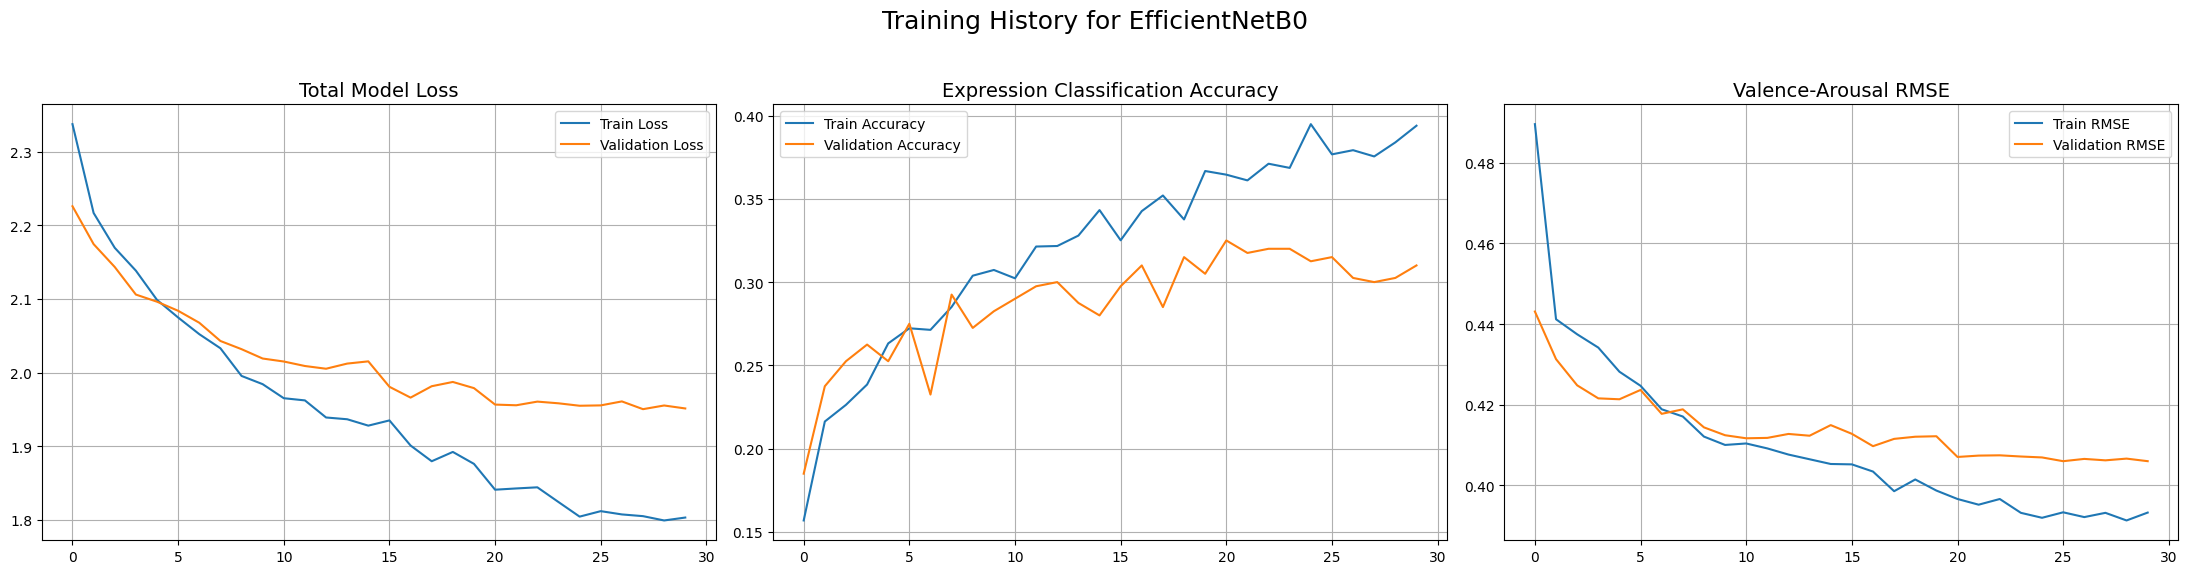



--- Visualizing Predictions from EfficientNetB0 ---
2/2 ━━━━━━━━━━━━━━━━━━━━ 9s 39ms/step


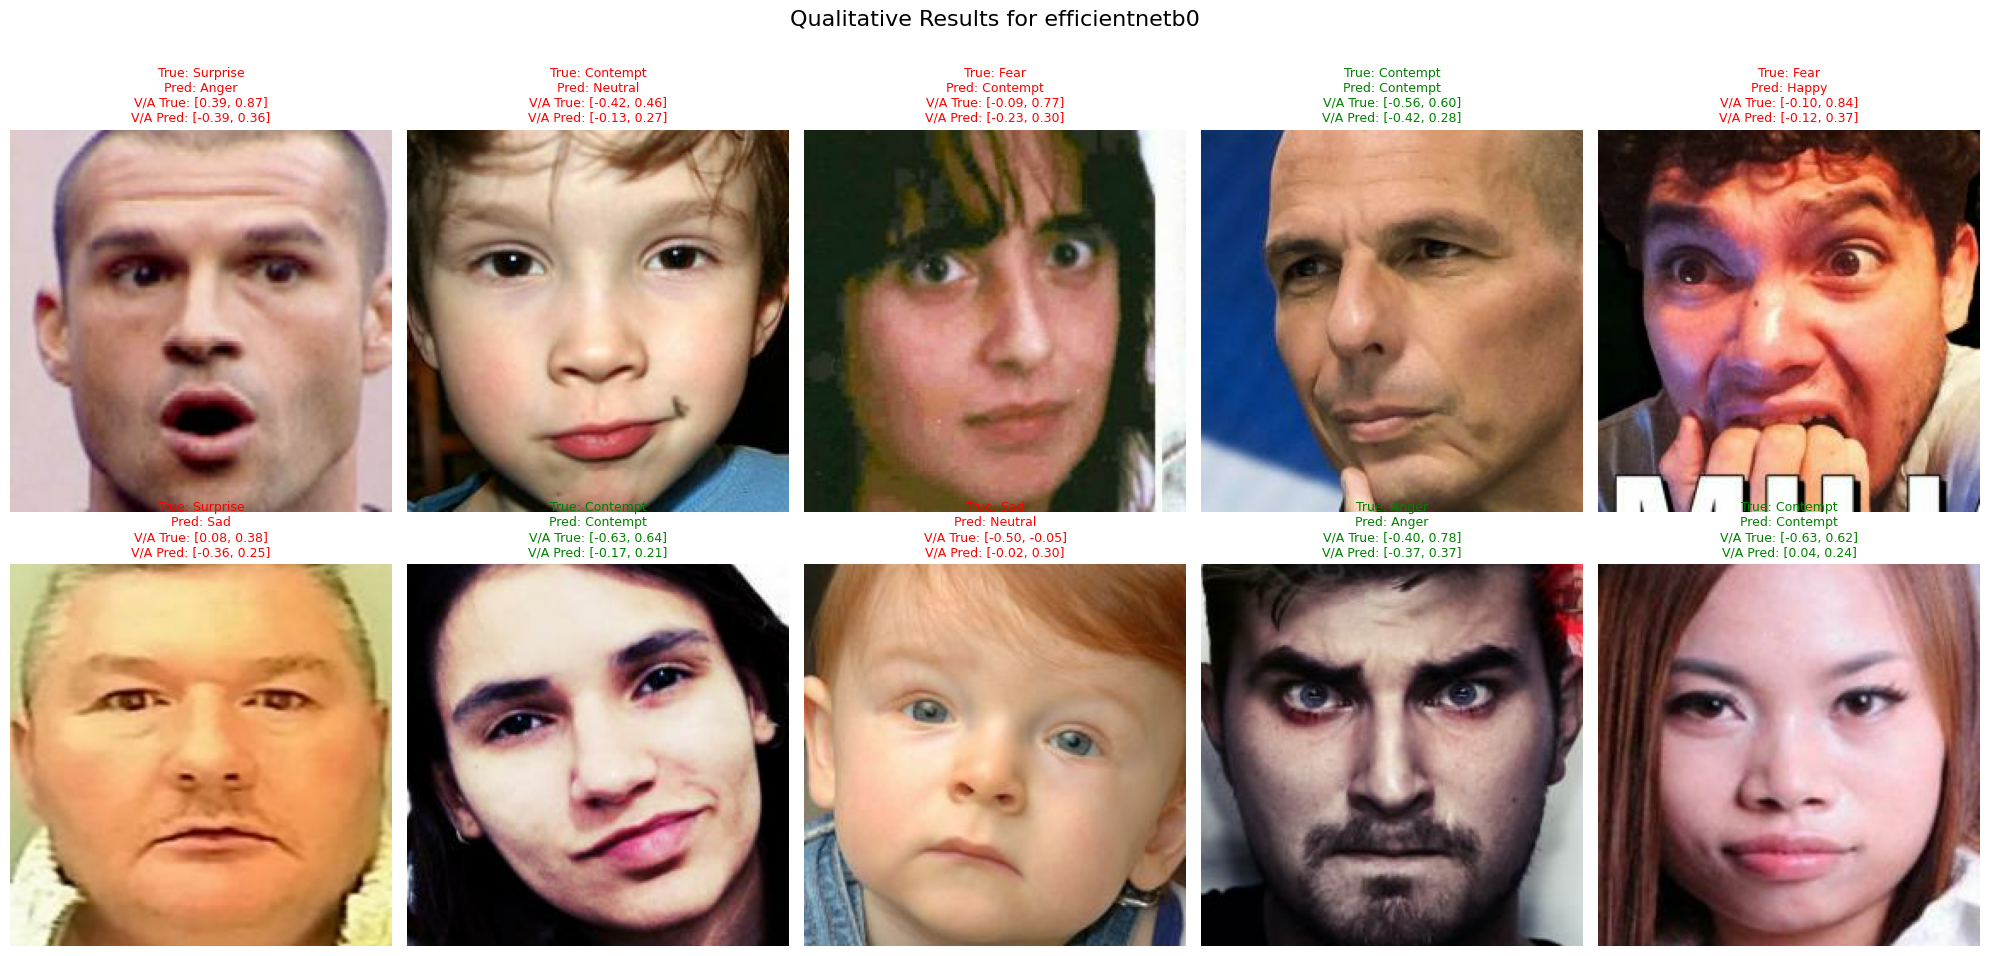

In [9]:
# ==============================================================================
# SECTION 8: VISUALIZATION OF RESULTS
# ==============================================================================

# --- Function to Plot Training History ---
def plot_training_history(history, model_name):
    fig, axes = plt.subplots(1, 3, figsize=(22, 6))
    fig.suptitle(f'Training History for {model_name}', fontsize=18)

    axes[0].plot(history.history['loss'], label='Train Loss')
    axes[0].plot(history.history['val_loss'], label='Validation Loss')
    axes[0].set_title('Total Model Loss', fontsize=14)
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(history.history['classification_head_accuracy'], label='Train Accuracy')
    axes[1].plot(history.history['val_classification_head_accuracy'], label='Validation Accuracy')
    axes[1].set_title('Expression Classification Accuracy', fontsize=14)
    axes[1].legend()
    axes[1].grid(True)

    axes[2].plot(history.history['regression_head_rmse'], label='Train RMSE')
    axes[2].plot(history.history['val_regression_head_rmse'], label='Validation RMSE')
    axes[2].set_title('Valence-Arousal RMSE', fontsize=14)
    axes[2].legend()
    axes[2].grid(True)
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

plot_training_history(history_resnet, "ResNet50V2")
plot_training_history(history_efficientnet, "EfficientNetB0")

# --- Function to Visualize Predictions ---
EXPRESSION_MAP = {0: 'Neutral', 1: 'Happy', 2: 'Sad', 3: 'Surprise', 4: 'Fear', 5: 'Disgust', 6: 'Anger', 7: 'Contempt'}

def visualize_predictions(model, dataset, df, num_samples=10):
    images, (true_class_oh, true_regr) = next(iter(dataset.take(1)))
    
    pred_class_probs, pred_regr = model.predict(images)
    pred_class = np.argmax(pred_class_probs, axis=1)
    
    true_class = np.argmax(true_class_oh.numpy(), axis=1)

    plt.figure(figsize=(20, 10))
    plt.suptitle(f'Qualitative Results for {model.layers[1].name}', fontsize=16)
    
    for i in range(num_samples):
        ax = plt.subplot(2, 5, i + 1)
        # We need to find the original image path from the dataframe for display
        # The test_df is shuffled, so we'll just grab the first few from our test set
        image_path_to_show = test_df.iloc[i]['image_path']
        raw_img = tf.io.read_file(image_path_to_show)
        raw_img = tf.image.decode_jpeg(raw_img)
        plt.imshow(raw_img)
        
        is_correct = (pred_class[i] == true_class[i])
        title_color = 'green' if is_correct else 'red'
        
        title = (f"True: {EXPRESSION_MAP[true_class[i]]}\n"
                 f"Pred: {EXPRESSION_MAP[pred_class[i]]}\n"
                 f"V/A True: [{true_regr[i, 0]:.2f}, {true_regr[i, 1]:.2f}]\n"
                 f"V/A Pred: [{pred_regr[i, 0]:.2f}, {pred_regr[i, 1]:.2f}]")
        
        plt.title(title, color=title_color, fontsize=9)
        plt.axis('off')
        
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

print("\n\n--- Visualizing Predictions from EfficientNetB0 ---")
# We use the test_df to get the correct image paths for visualization
visualize_predictions(efficientnet_model, test_ds_effnet, test_df)